Unsupervised ML is a set of algorithm applied on unlabelled data to get insights and help 
to understand the data set much more better. 

Casestudy: M&B Insurance company to help overcome the challenges of understanding and 
catering the diverse need of customers.

Perform a Customer Personality Analysis and gain insight in customer behaviour, interest and preference.

Problem Objective: Using Unsupervised Machine Learning 

Whats is Market Segmentation: It is the process of dividing a broad consumer or business market normally consist of existing potentials customers into subgroupds of consumers based n some types of shared characteristics. Unsupervised ML Models are perfect for tese kind of tasks.

Objective: The case requires developinga customer segmentation to give recommendations like saving plans, loans, weath management etc. o target customer groups.

The goal of this project is to perform Exploratory Analysis and a Customer
Personality Analysis, this will aid you segment customers based on their
Insurance Profile behavior and information. 

We will use unsupervised learning techniques like Dimensionality Reduction
( and Clustering to identify groups of customers with similar behavior and
characteristic.

In [5]:
! pip install yellowbrick
! pip install mpl_toolkits


#importing relevant libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib import colors
from mpl_toolkits.mplot3d import Axes3D


import warnings
warnings.filterwarnings("ignore")


ERROR: Could not find a version that satisfies the requirement mpl_toolkits (from versions: none)
ERROR: No matching distribution found for mpl_toolkits


In [6]:
#reading in data
df=pd.read_csv('Customer Data_insurance.csv')

In [7]:
# Univariate, Bivariate and Multivariate Analysis

ACCESSING THE DATA

In [8]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [9]:
df.shape

(8950, 18)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [11]:
#statistical describtion of data set
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [12]:
#checking for missing features
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [13]:
#filling in of missing inputs by filling na it up with the mean values
# ideally check the distribution of the data to check for outliers and determine the best method of filling the missing values
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].mean())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].mean())

In [14]:
# Check for duplicates
print (df.duplicated().sum())


0


In [15]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [16]:
# Drop CustomerID as it redundant to the data analysis. Here Customer ID is identifier for customers, 
# not relevant to the Analysis and adds no information to the Analysis

In [17]:
#dropping of redundant features
df.drop(columns=["CUST_ID"],axis=1,inplace=True)

In [18]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [19]:
df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

Exploratory Data Analysis

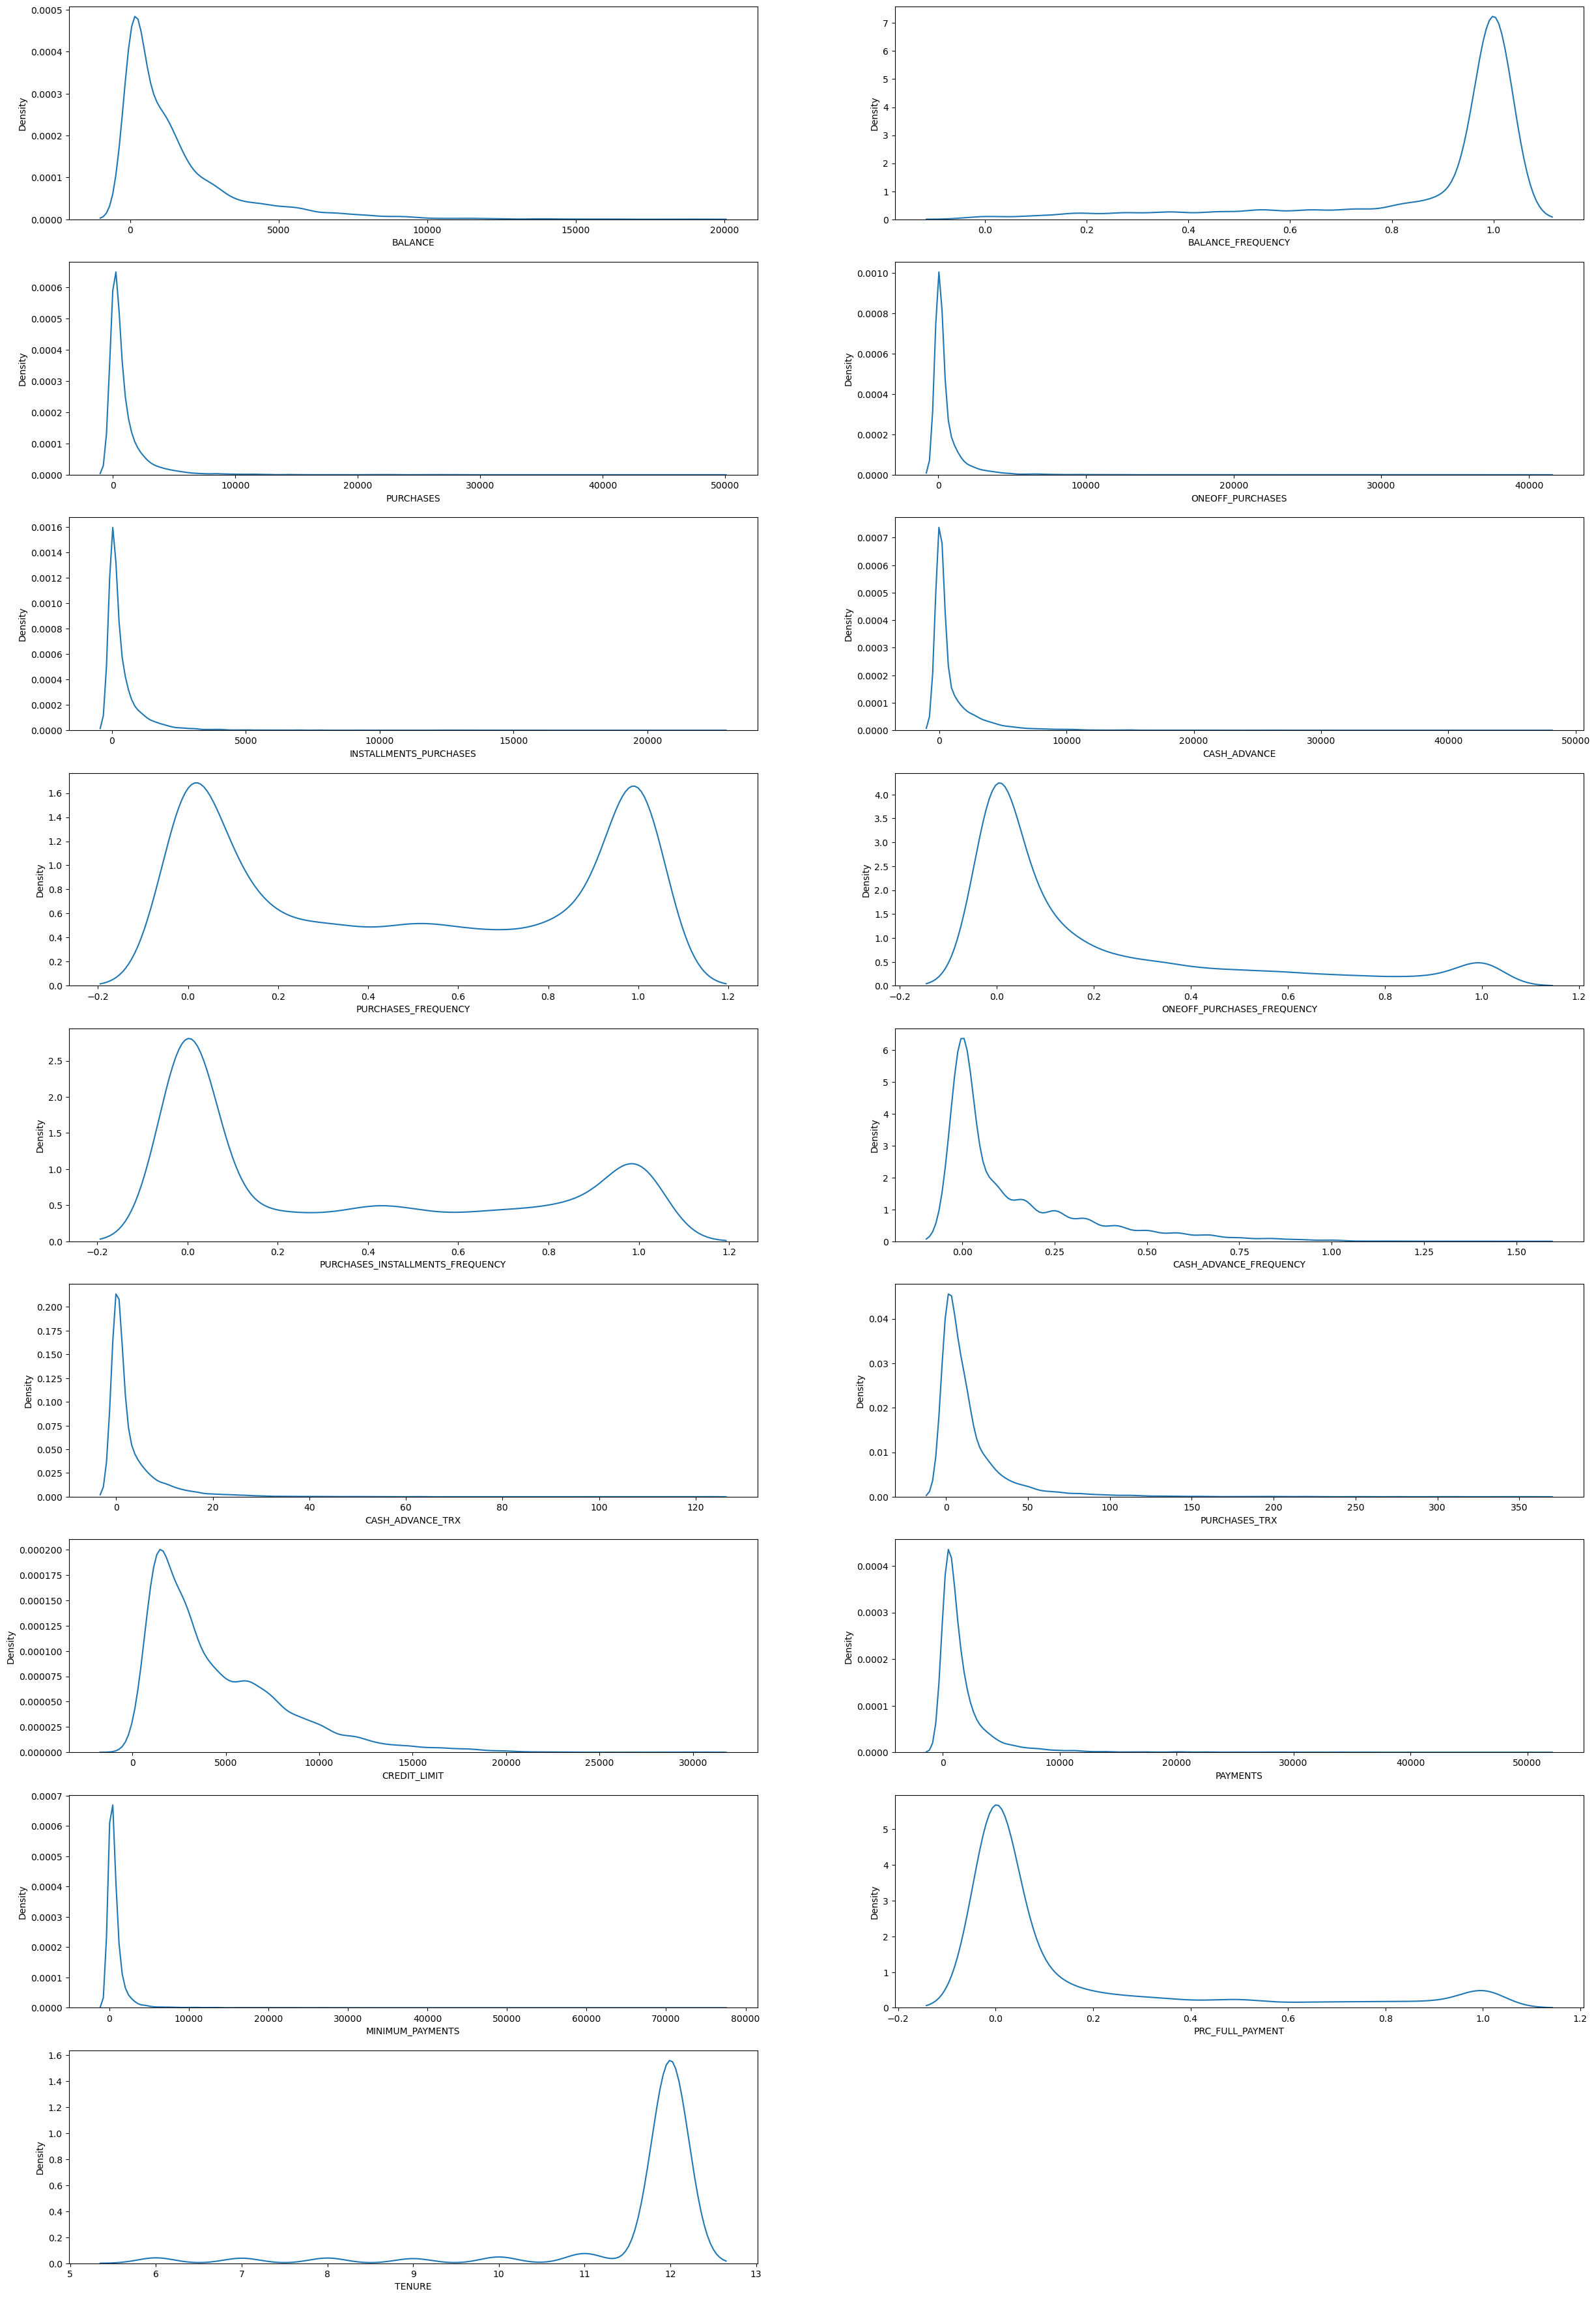

In [20]:
#multivariate analsysis
#density estimation plots of all numerical features
plt.figure(figsize=(30,45))
for i, col in enumerate(df.columns):
    if df[col].dtype != 'object':
        ax = plt.subplot(9, 2, i+1)
        sns.kdeplot(df[col], ax=ax)
        plt.xlabel(col)

plt.show()

## The above analysis tells us how the columns / features is skewed to the left or right.

## Positive Skewed/ Right Skewed Distribution

- If skewed right it means Rightly Skewed, the data is concentrated to the left with mean>median (Positive) Have Outliers  

## Negative Skewed / Left Skewed Distribution

- If skewed left it means Left Skewed, the data is concentrated to the right with mean<median (Negative) No Outliers

In [21]:
# To show the density distribution of the plot /data 


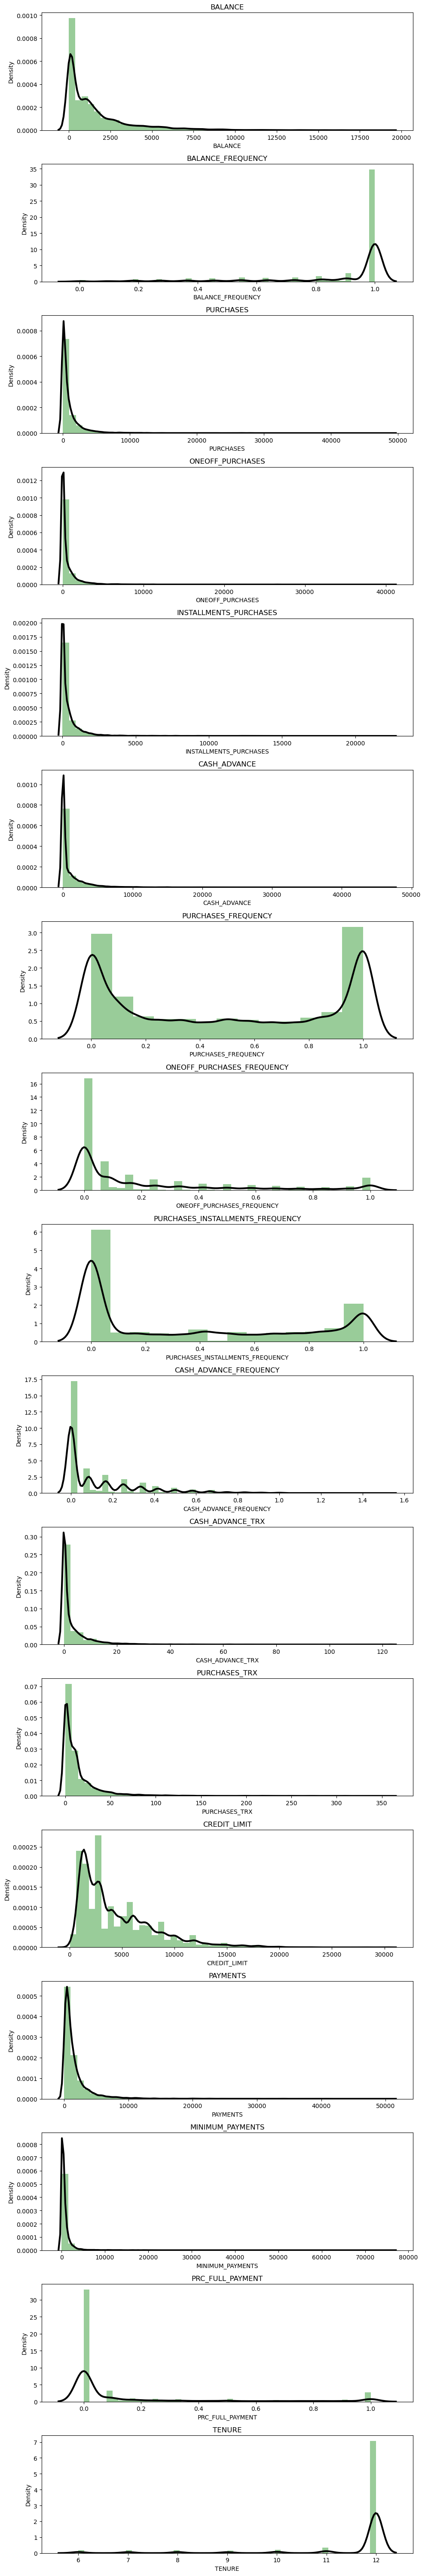

In [22]:
#multivariate analysis
#distribution plots of all the numerical features

plt.figure(figsize=(10,60))
for i in range(0,17):
    plt.subplot(17,1,i+1)
    sns.distplot(df[df.columns[i]],kde_kws={'color':'black','bw': 0.1,'lw':3,'label':'KDE'},hist_kws={'color':'g'})
    plt.title(df.columns[i])
plt.tight_layout()

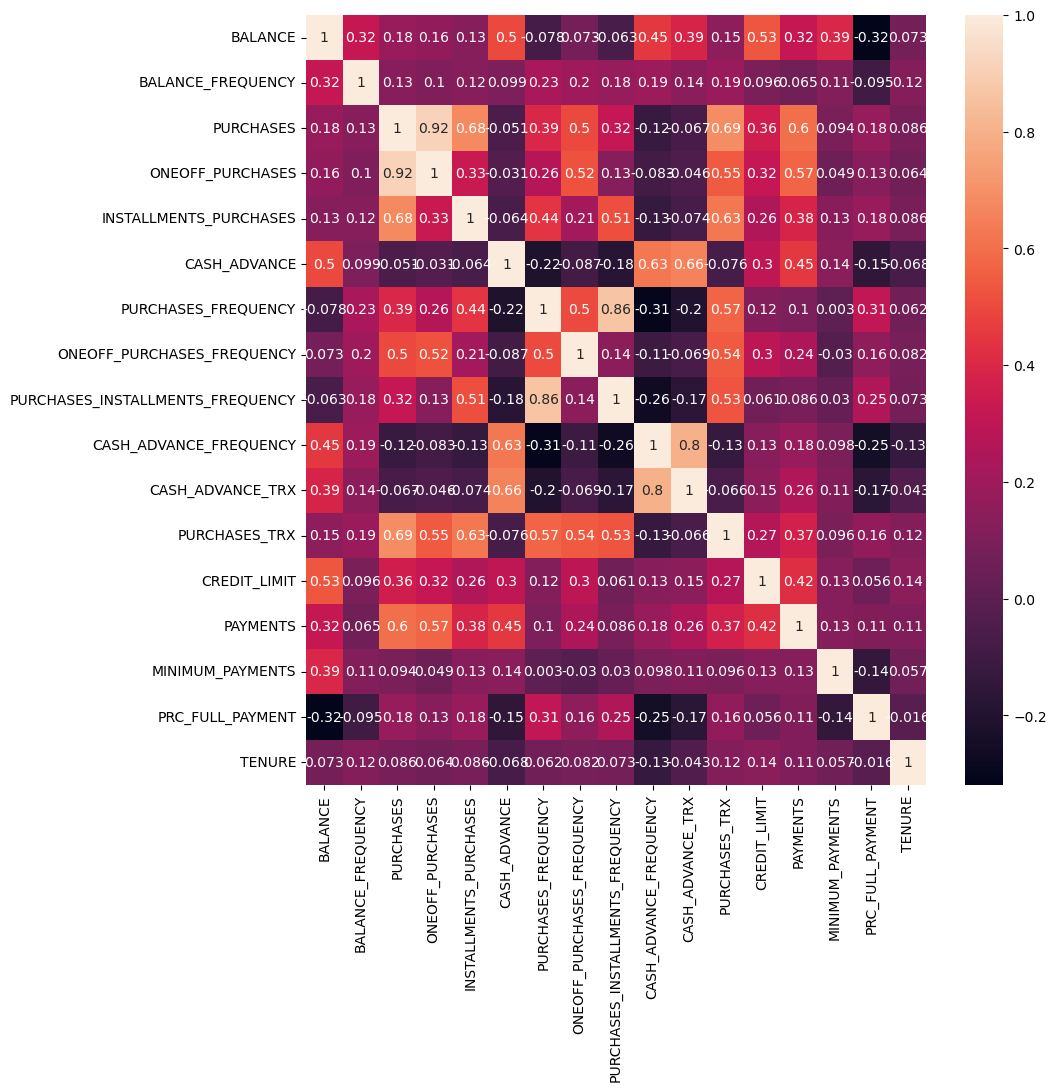

In [23]:
#multiariate analsyis
#heatmap correlation plot
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

Naration: 
    
    - Purchases and Oneoff Purchases are strongly positively correlated
    - Purchase Frequency and Purchase installments  frequency are positively correlated
    - Cash advance trxn and Cash advance fequency are positively correlated
    

## UNSPERVISED MACHINE LEARNING SECTION

DIMENSIONALITY REDUCTION: More input featuresoftenmake a predictive modeling taks more challenging to model, 
more generally refered to as the cause of dimentionsality. 

Dimensionality reduction refers to techniques that reduce the number of input variables in a dataset.

Principal Componenet Analysis (PCA) 

Is a technique for reducing the dimensions of a large dataset, increasing the interpreatblilty and at the same minimizing information loss
other exmaples of Dimensionality Reduction techniques include Self Organizing Maps (SOM), t-distributed Stochastic Neighbor Embedding (t-SNE) etc.

CLUSTERING: Clustering is the process of arranging a group of objects in such a manner that the objects in the same group (which is referred to as a cluster) are more similar to each other than to the objects in any other group

Kmeans Clustering Algorithm is It is a centroid-based algorithm where the user must define the required number of clusters it wants to create
other examples of clustering algorithms are Agglomerative CL, DBSCAN, Spectral Clustering etc.

In [24]:
# importing relevant libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN,SpectralClustering
from yellowbrick.cluster import KElbowVisualizer



In [25]:
#task 
#BUILD CLUSTERING MODEL without reducing the Dimensions
#Build Model with Reduced Dimensions

#### ML dont understand Categorical data, change categorical data to integers or float Using Labelencoder.

In [26]:
# encode categorical data into num data
cat_feat = (df.dtypes =="object")
cat_feat =list(cat_feat[cat_feat].index)

encoder =LabelEncoder()
for i in cat_feat:
    df[i] = df[[i]].apply(encoder.fit_transform)

In [27]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)  # Standardize the data

# Create a DataFrame from the scaled data
df = pd.DataFrame(scaled_data, columns=df.columns)

In [28]:
# normalize data ie standardize dataset
# scaler = StandardScaler()
# df = pd.DataFrame(scaler.fit_transform(df),columns=df.columns)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df = pd.DataFrame(scaler.fit_transform(df),columns=df.columns)



In [29]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.002148,0.818182,0.001945,0.000000,0.00424,0.000000,0.166667,0.000000,0.083333,0.000000,0.00000,0.005587,0.031720,0.003979,0.001826,0.000000,1.0
1,0.168169,0.909091,0.000000,0.000000,0.00000,0.136685,0.000000,0.000000,0.000000,0.166667,0.03252,0.000000,0.232053,0.080893,0.014034,0.222222,1.0
2,0.131026,1.000000,0.015766,0.018968,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.033520,0.248748,0.012264,0.008210,0.000000,1.0
3,0.087521,0.636364,0.030567,0.036775,0.00000,0.004366,0.083333,0.083333,0.000000,0.055555,0.00813,0.002793,0.248748,0.000000,0.011310,0.000000,1.0
4,0.042940,1.000000,0.000326,0.000393,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.038397,0.013374,0.003204,0.000000,1.0


In [30]:
# Dimensionality reduction using PCA 
# PCA is to reduce the large dataset into smaller components but the has information as the original data set, 
# this make the ML easier to understand, get more reasonable result and interprete while retaining vital information 
# ie reducing the noise and summarize the data
# PCA -It is used to creat a smaller version of the original dataset and still carries all of the information of the original dataset
pca =PCA(n_components=3)
pca_df=pd.DataFrame(pca.fit_transform(df), columns=(["col1","col2","col3"]))
pca_df.head()

,col1,col2,col3
0,-0.482164,-0.097656,-0.046457
1,-0.608577,-0.019379,0.082143
2,0.304507,0.920946,0.012042
3,-0.588622,-0.005605,0.036900
4,-0.554354,0.052965,-0.084179


In [31]:
pca.explained_variance_ratio_ # Also called Eigen Vectors amount of info each component has. 
# Components that explain the majority of data, as component increase the ability to explain the dataset decreases.

array([0.49597206, 0.14054044, 0.12844489])

Text(0.5, 0.92, '3d visualization of our new dimensions')

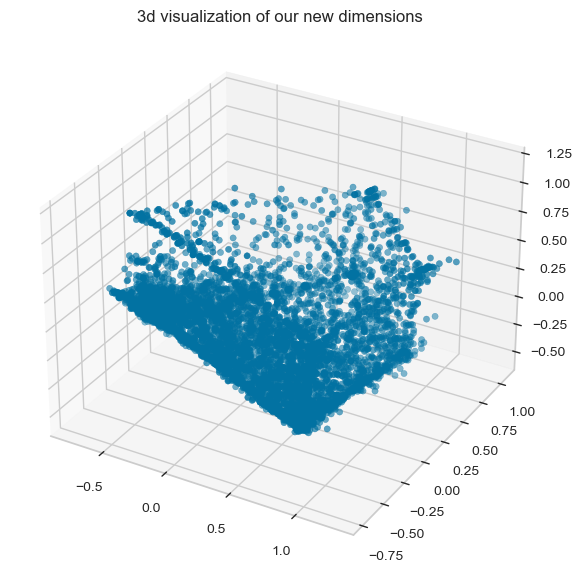

In [32]:
#visualizing our new data dimension 

x=pca_df["col1"]
y=pca_df["col2"]
z=pca_df["col3"]

fig = plt.figure(figsize = (10,7))
ax=fig.add_subplot(111,projection ="3d")
ax.scatter(x,y,z,marker="o")
ax.set_title("3d visualization of our new dimensions")


In [33]:
# Clustering Section

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=10))

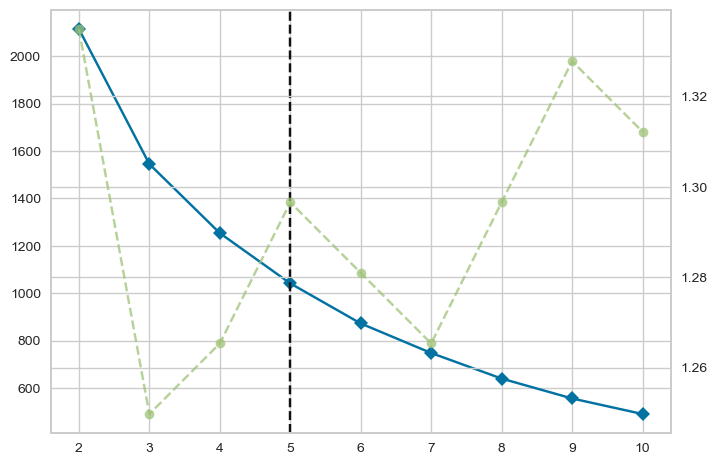

In [34]:
# Using the K-Elbow method to figure /determine the appropriate number of clusters
elbow_k=KElbowVisualizer(estimator=KMeans())
elbow_k.fit(pca_df)

In [35]:
# apply kmeans clustering

In [36]:
kmeans = KMeans(n_clusters=5,random_state=0)
y_means = kmeans.fit_predict(pca_df)
pca_df["clusters"] =y_means
df["clusters"] =y_means

In [37]:
# pca_df

In [38]:
pca_df.clusters.value_counts()

1    3605
3    1921
0    1481
2    1080
4     863
Name: clusters, dtype: int64

Text(0.5, 0.92, '3d visualization of our data by their clusters')

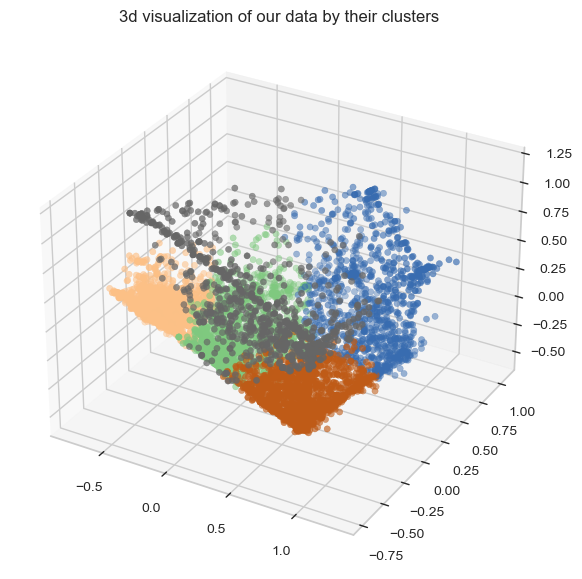

In [39]:
#plotting new data points 
cmap = "Accent"
fig = plt.figure(figsize=(10,7))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x,y,z,c=pca_df['clusters'],marker="o",cmap=cmap)
ax.set_title("3d visualization of our data by their clusters")



Text(0.5, 1.0, 'distribution of the new clusters')

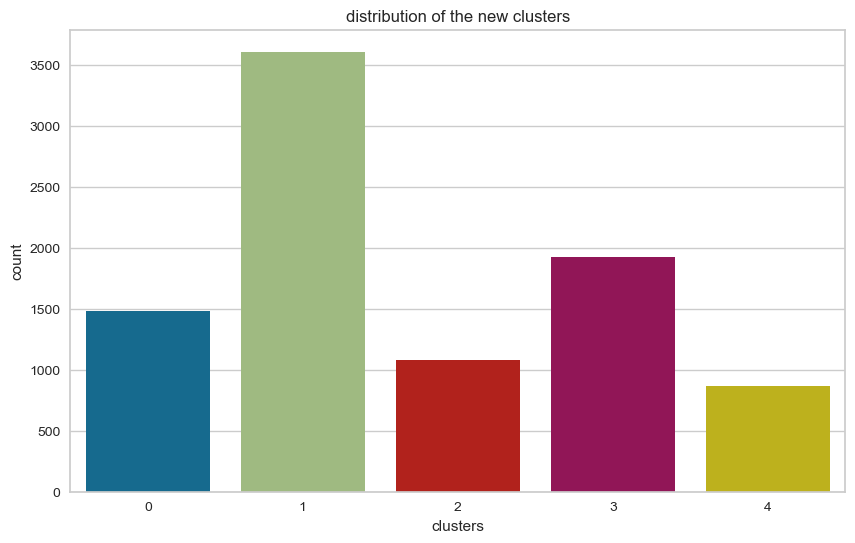

In [40]:
plt.figure(figsize=(10,6))
sns.countplot(x = pca_df.clusters)
plt.title("distribution of the new clusters")

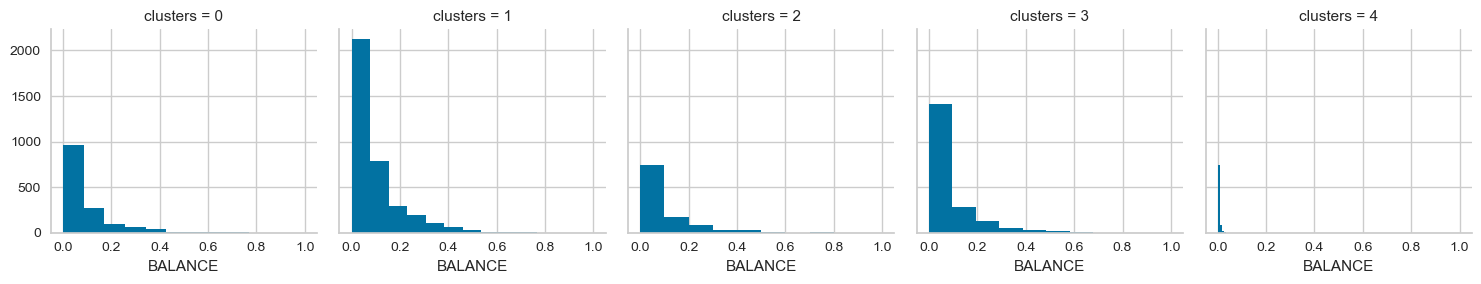

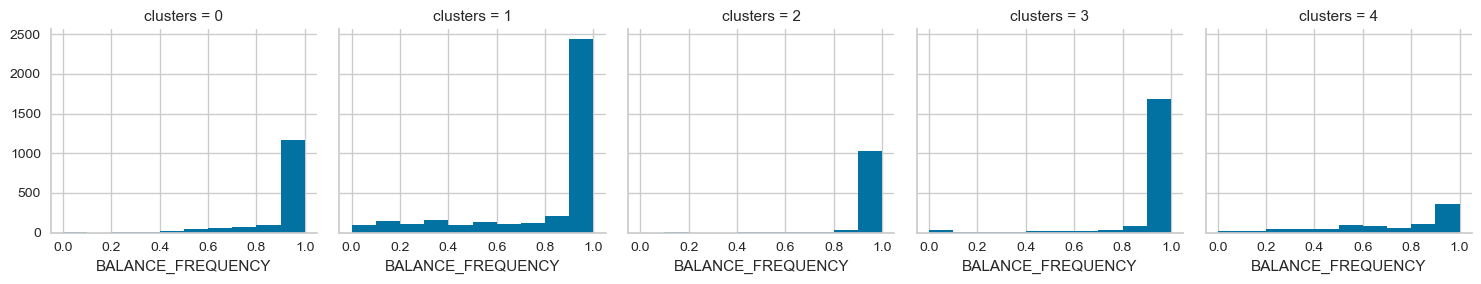

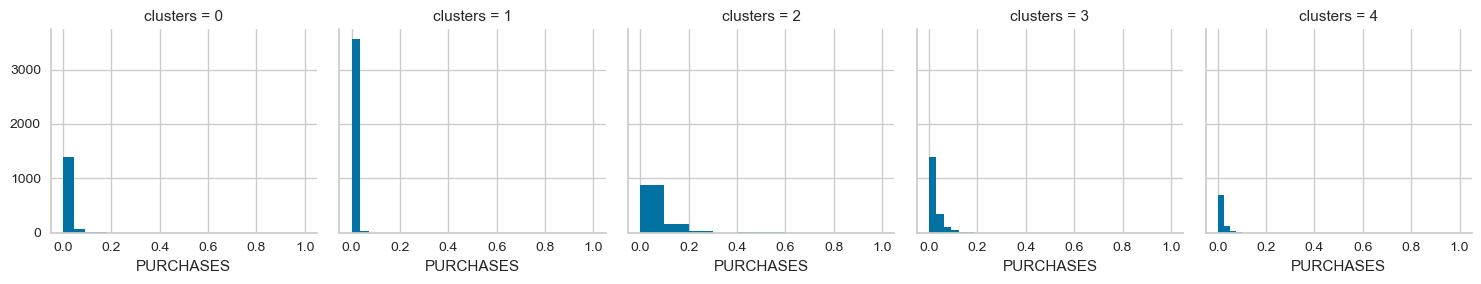

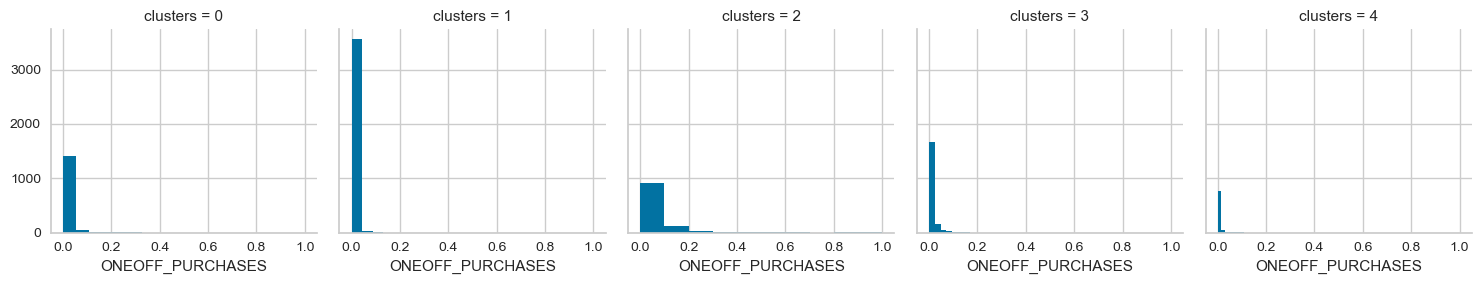

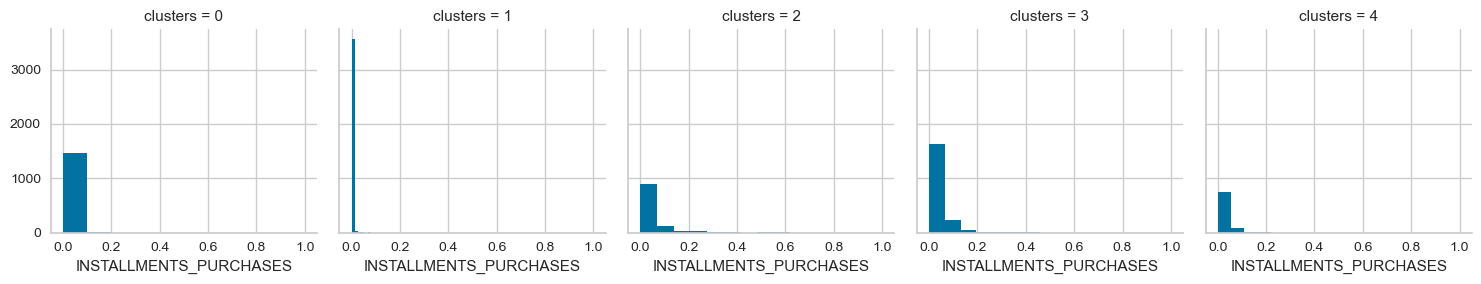

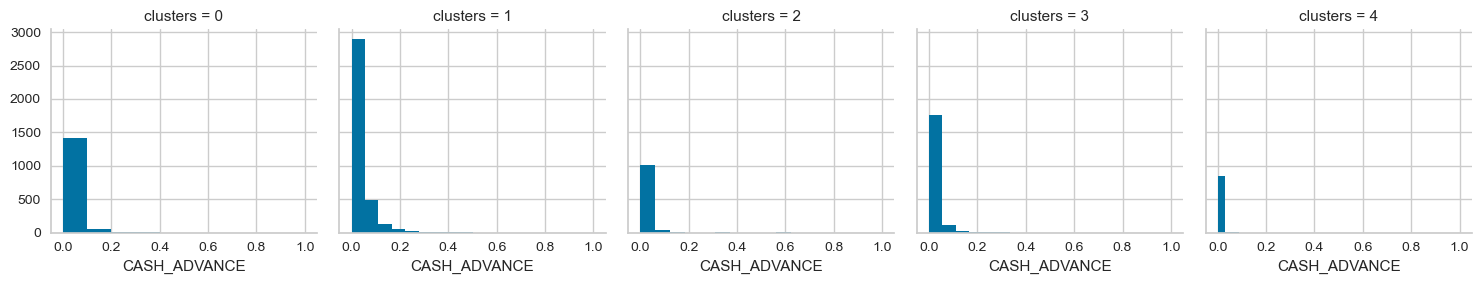

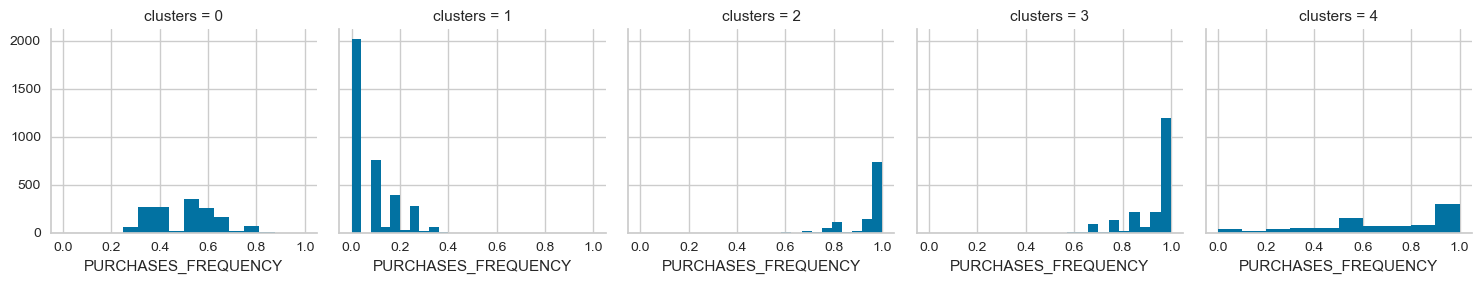

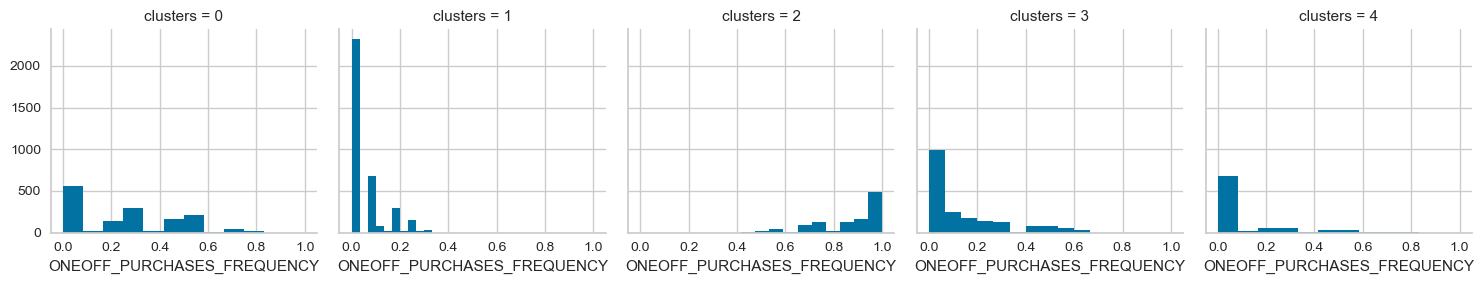

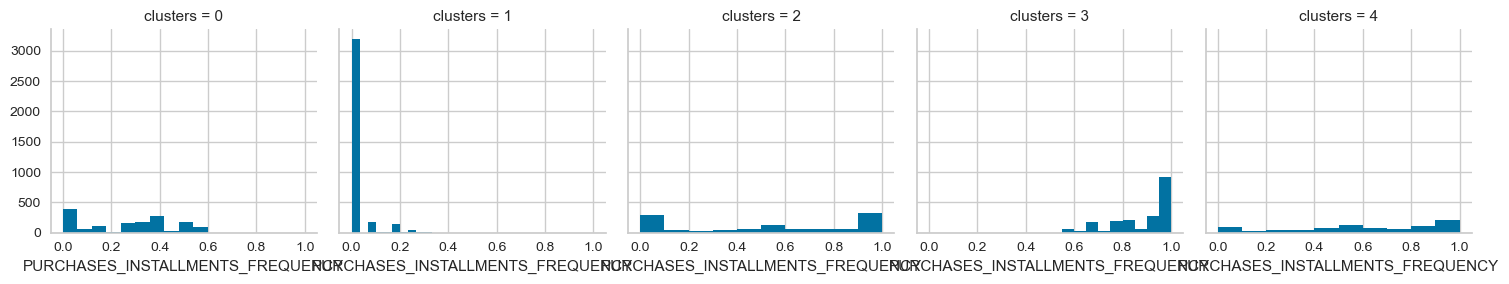

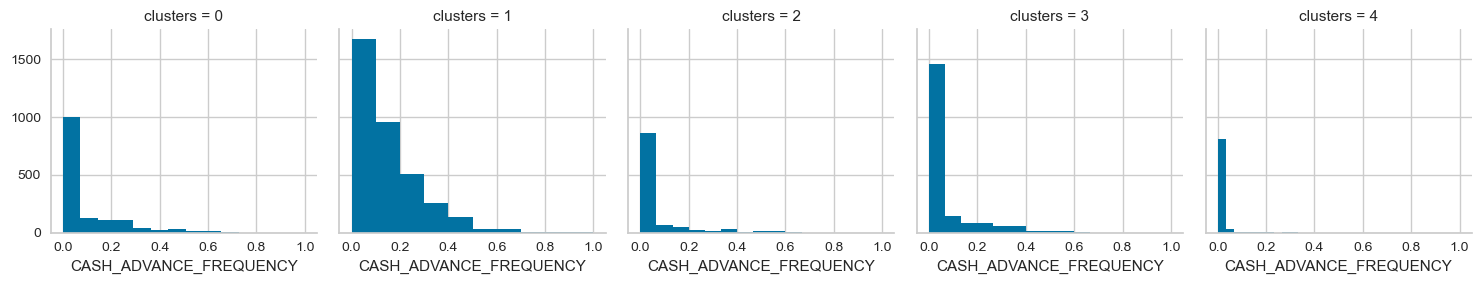

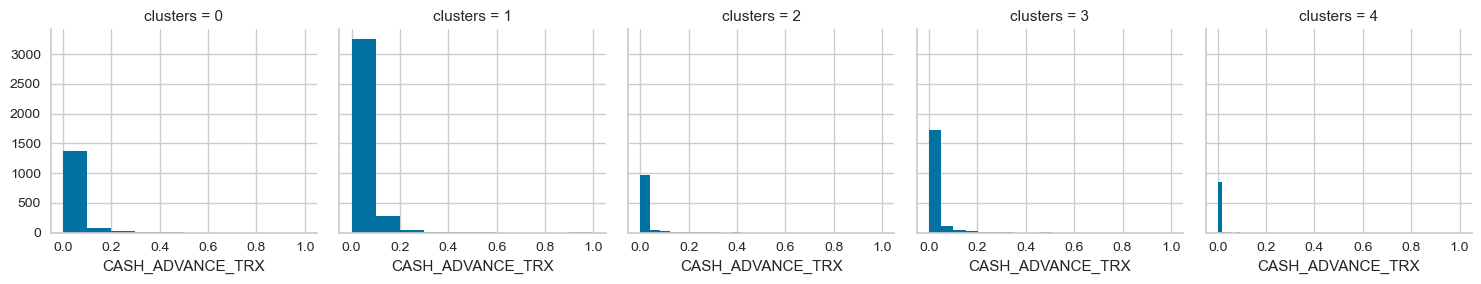

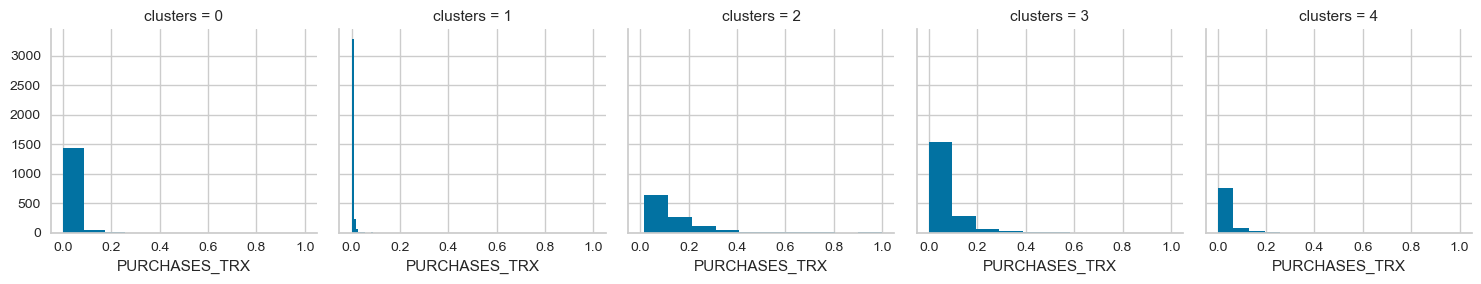

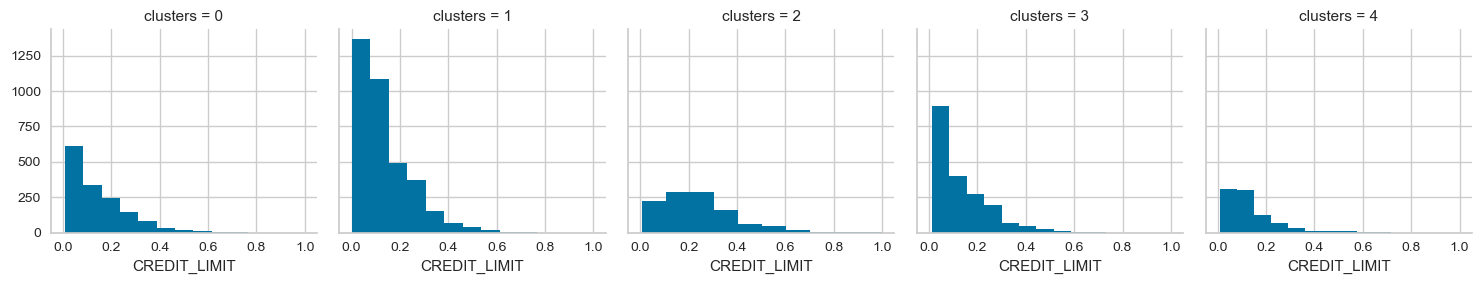

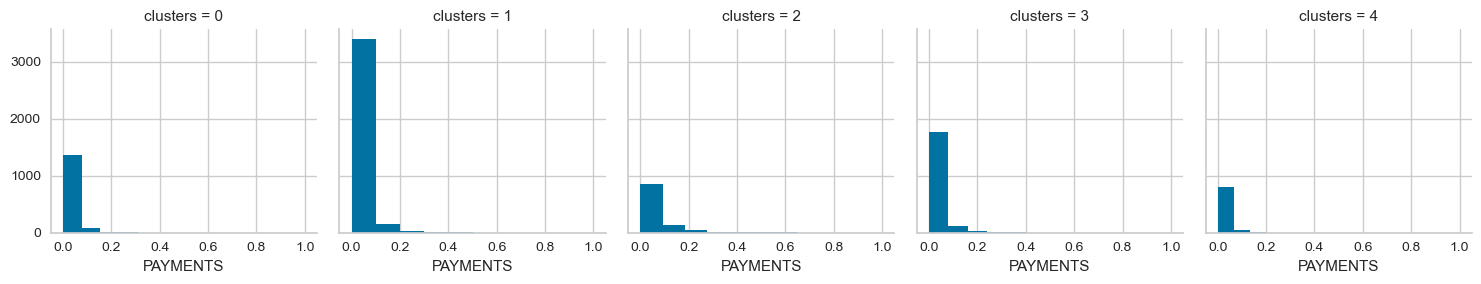

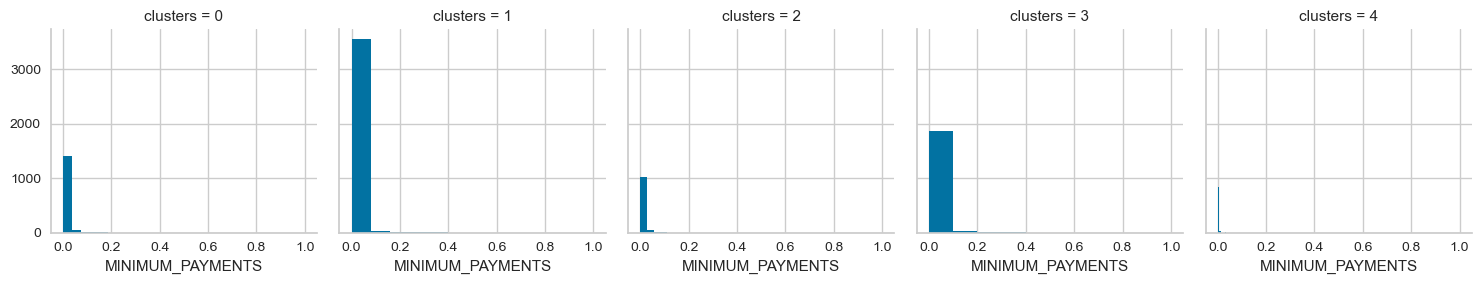

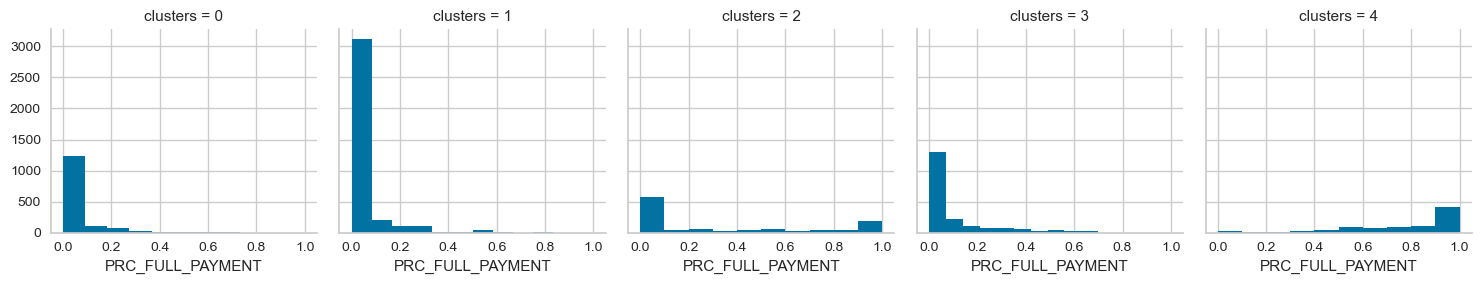

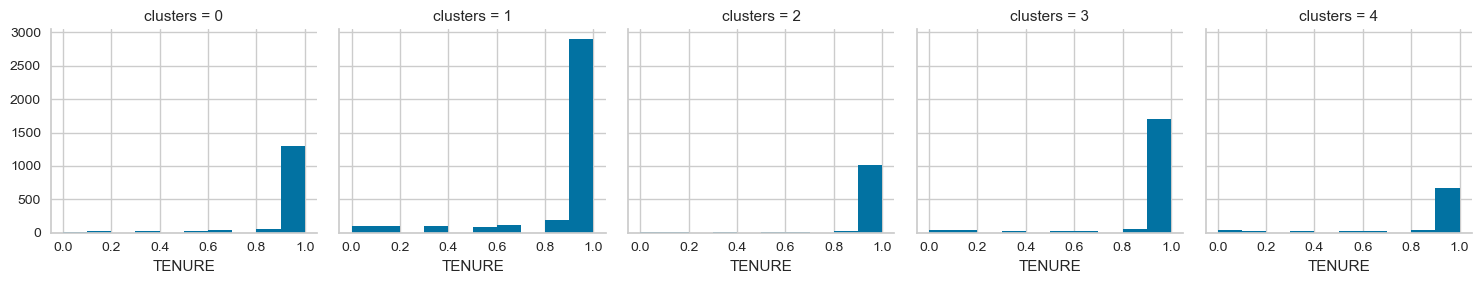

In [41]:
for c in df.drop(["clusters"],axis=1):
    grid = sns.FacetGrid(df,col="clusters")
    grid =grid.map(plt.hist,c)

<AxesSubplot:xlabel='BALANCE', ylabel='Count'>

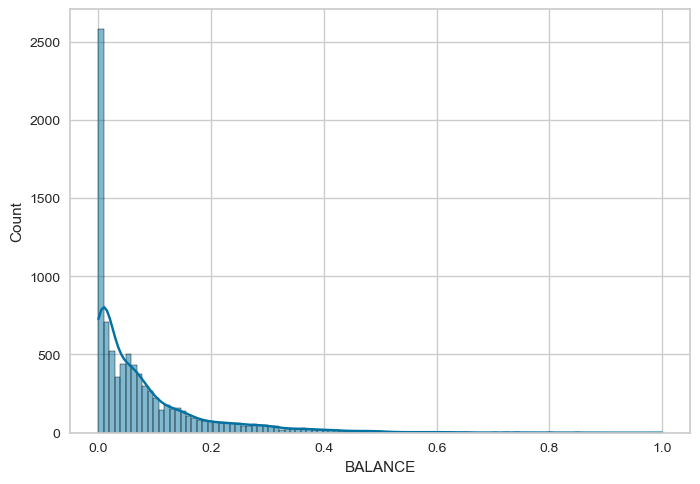

In [42]:
for c in df.drop(["clusters"],axis=1):
    grid = sns.FacetGrid(df,col="clusters")
    grid =grid.map(plt.hist,c)

<AxesSubplot:xlabel='clusters', ylabel='BALANCE'>

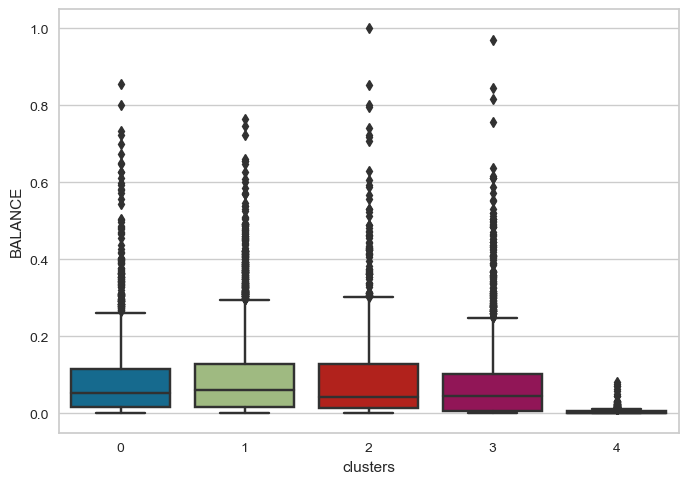

In [43]:
sns.boxplot(x="clusters",y="BALANCE",data=df)